# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [3]:
import pandas as pd

df = pd.read_csv('frequencia_aminoacidos.csv')

def tendencia_central(dados):
    dados = pd.to_numeric(dados, errors='coerce')  # garante que tudo é número
    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()
    return media, mediana, moda

media_S, mediana_S, moda_S = tendencia_central(df['S'])

print("Serina:")
print(media_S, mediana_S)
print(moda_S)

terceiro_gene = df.iloc[2].select_dtypes('number') if hasattr(df.iloc[2], 'select_dtypes') else df.iloc[2]

terceiro_gene = df.iloc[2, 1:] 

media_g3, mediana_g3, moda_g3 = tendencia_central(terceiro_gene)

print("\nTerceiro gene:")
print(media_g3, mediana_g3)
print(moda_g3)

Serina:
46.6 57.0
0    17
1    25
2    57
3    58
4    76
Name: S, dtype: int64

Terceiro gene:
40.8 43.5
0    20
Name: 2, dtype: int64


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [7]:
df = pd.read_csv('frequencia_aminoacidos.csv')

def amplitude(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    return dados.max() - dados.min()

amplitude_isoleucina = amplitude(df['I'])
print("Amplitude da Isoleucina:", amplitude_isoleucina)
ultimo_gene = df.iloc[-1, 1:]
amplitude_ultimo_gene = amplitude(ultimo_gene)
print("Amplitude do último gene:", amplitude_ultimo_gene)

Amplitude da Isoleucina: 27
Amplitude do último gene: 18


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [8]:
df = pd.read_csv('frequencia_aminoacidos.csv')
def quartis(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)
    q3 = dados.quantile(0.75)
    return q1, q2, q3
q1_M, q2_M, q3_M = quartis(df['M'])

print("Metionina:")
print("Q1:", q1_M)
print("Q2:", q2_M)
print("Q3:", q3_M)

primeiro_gene = df.iloc[0, 1:]
q1_g1, q2_g1, q3_g1 = quartis(primeiro_gene)

print("\nPrimeiro gene:")
print("Q1:", q1_g1)
print("Q2:", q2_g1)
print("Q3:", q3_g1)

Metionina:
Q1: 6.0
Q2: 8.0
Q3: 8.0

Primeiro gene:
Q1: 6.5
Q2: 13.5
Q3: 25.0


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

IQR Ácido Glutâmico: 21.0
IQR penúltimo gene: 12.5


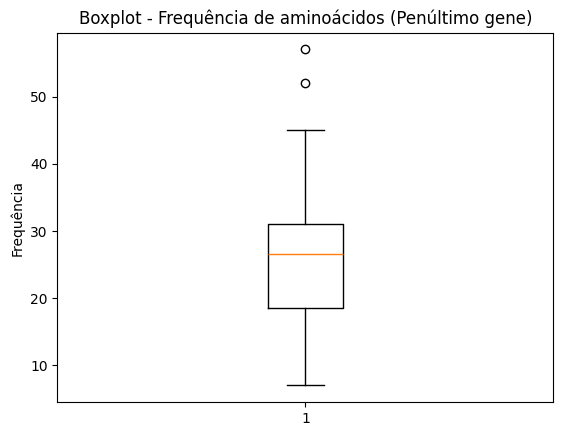

In [10]:
import matplotlib.pyplot as plt
df = pd.read_csv('frequencia_aminoacidos.csv')
def iqr(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    return q3 - q1
iqr_glutamico = iqr(df['E'])
print("IQR Ácido Glutâmico:", iqr_glutamico)
penultimo_gene = df.iloc[-2, 1:]  
iqr_penultimo = iqr(penultimo_gene)
print("IQR penúltimo gene:", iqr_penultimo)
plt.figure()
plt.boxplot(penultimo_gene.astype(float))
plt.title("Boxplot - Frequência de aminoácidos (Penúltimo gene)")
plt.ylabel("Frequência")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [11]:
df = pd.read_csv('frequencia_aminoacidos.csv')
def variancia(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    return dados.var(ddof=1) 
var_prolina = variancia(df['P'])
print("Variância da Prolina:", var_prolina)
terceiro_gene = df.iloc[2, 1:]
var_terceiro_gene = variancia(terceiro_gene)
print("Variância do terceiro gene:", var_terceiro_gene)

Variância da Prolina: 639.1999999999999
Variância do terceiro gene: 382.27368421052626


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [12]:
df = pd.read_csv('frequencia_aminoacidos.csv')
def desvio_padrao(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    return dados.std(ddof=1)  
dp_triptofano = desvio_padrao(df['W'])
print("Desvio padrão do Triptofano:", dp_triptofano)
ultimo_gene = df.iloc[-1, 1:]  
dp_ultimo_gene = desvio_padrao(ultimo_gene)
print("Desvio padrão do último gene:", dp_ultimo_gene)

Desvio padrão do Triptofano: 3.974921382870358
Desvio padrão do último gene: 5.704107476657777


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [13]:
df = pd.read_csv('frequencia_aminoacidos.csv')
def coef_variacao(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    media = dados.mean()
    desvio = dados.std(ddof=1)
    return desvio / media
cv_leucina = coef_variacao(df['L'])
print("Coeficiente de variação da Leucina:", cv_leucina)
gene_1 = df.iloc[1, 1:] 
cv_gene_1 = coef_variacao(gene_1)
print("Coeficiente de variação do gene index 1:", cv_gene_1)

Coeficiente de variação da Leucina: 0.5258920991990658
Coeficiente de variação do gene index 1: 0.6051305206975047


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [15]:
def medidas_resumo(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    
    resumo = {
        "media": dados.mean(),
        "mediana": dados.median(),
        "moda": dados.mode().iloc[0],
        "minimo": dados.min(),
        "maximo": dados.max(),
        "amplitude": dados.max() - dados.min(),
        "q1": dados.quantile(0.25),
        "q2": dados.quantile(0.50),
        "q3": dados.quantile(0.75),
        "variancia": dados.var(ddof=1),
        "desvio_padrao": dados.std(ddof=1),
        "coef_variacao": dados.std(ddof=1) / dados.mean()
    }
    
    return resumo

res_leucina = medidas_resumo(df['L'])
print("=== Leucina ===")
for chave, valor in res_leucina.items():
    print(chave, ":", valor)
gene_1 = df.iloc[1, 1:]
res_gene1 = medidas_resumo(gene_1)
print("\n=== Gene index 1 ===")
for chave, valor in res_gene1.items():
    print(chave, ":", valor)

=== Leucina ===
media : 40.0
mediana : 51.0
moda : 9
minimo : 9
maximo : 60
amplitude : 51
q1 : 28.0
q2 : 51.0
q3 : 52.0
variancia : 442.5
desvio_padrao : 21.03568396796263
coef_variacao : 0.5258920991990658

=== Gene index 1 ===
media : 27.0
mediana : 23.0
moda : 11
minimo : 8
maximo : 58
amplitude : 50
q1 : 14.0
q2 : 23.0
q3 : 36.25
variancia : 266.94736842105266
desvio_padrao : 16.33852405883263
coef_variacao : 0.6051305206975047


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

Gene com maior CV: BRCA1
Valor do CV: 0.6367145399670132


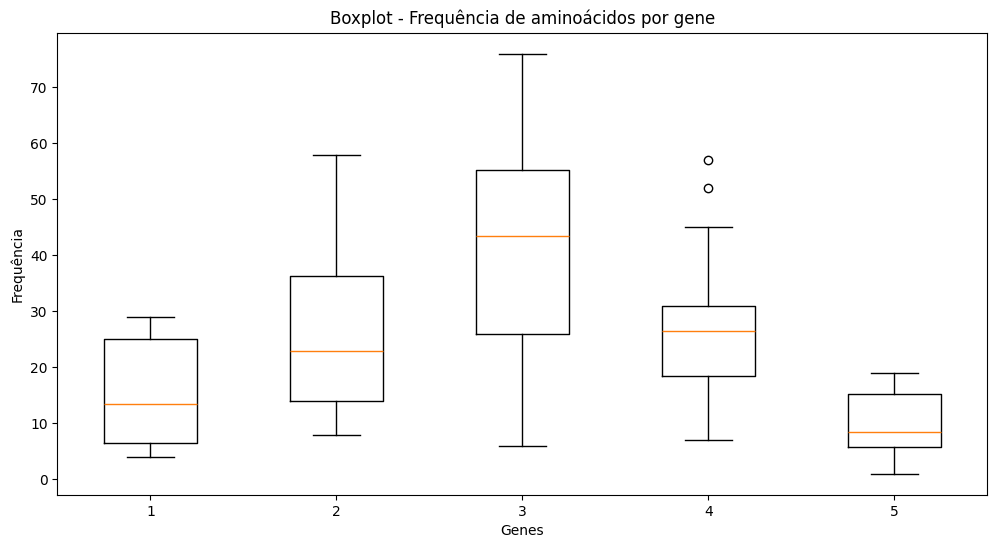

In [16]:
def coef_variacao(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    return dados.std(ddof=1) / dados.mean()
cv_genes = {}
for i in range(len(df)):
    nome_gene = df.iloc[i, 0]   
    valores = df.iloc[i, 1:]      
    cv_genes[nome_gene] = coef_variacao(valores)
gene_maior_cv = max(cv_genes, key=cv_genes.get)
print("Gene com maior CV:", gene_maior_cv)
print("Valor do CV:", cv_genes[gene_maior_cv])
plt.figure(figsize=(12, 6))
dados_numericos = df.iloc[:, 1:].astype(float)
plt.boxplot(dados_numericos.T)
plt.title("Boxplot - Frequência de aminoácidos por gene")
plt.xlabel("Genes")
plt.ylabel("Frequência")
plt.show()

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Aminoácido com maior CV: Q
Valor do CV: 0.8385967844446642


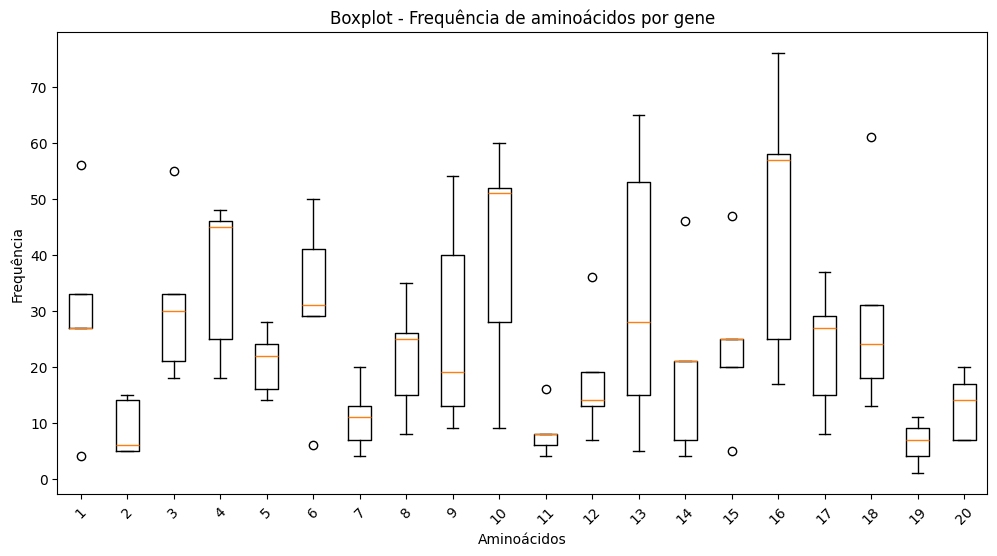

In [17]:
def coef_variacao(dados):
    dados = pd.to_numeric(dados, errors='coerce')
    return dados.std(ddof=1) / dados.mean()
cv_aminoacidos = {}
for coluna in df.columns[1:]: 
    cv_aminoacidos[coluna] = coef_variacao(df[coluna])
amino_maior_cv = max(cv_aminoacidos, key=cv_aminoacidos.get)
print("Aminoácido com maior CV:", amino_maior_cv)
print("Valor do CV:", cv_aminoacidos[amino_maior_cv])
plt.figure(figsize=(12, 6))
dados_amino = df.iloc[:, 1:].astype(float)
plt.boxplot(dados_amino)
plt.title("Boxplot - Frequência de aminoácidos por gene")
plt.xlabel("Aminoácidos")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()